# Test 4b: FAO-56 Independent Validation with pyfao56

This notebook compares SWB2's FAO-56 crop coefficient and water balance results against an independent Python implementation ([pyfao56](https://github.com/kthorp/pyfao56), Thorp 2022). Both codes are fed identical climate inputs (from SWB2's DUMP_VARIABLES output) so that differences reflect only the algorithmic implementations.

## References

- Allen, R.G., Pereira, L.S., Raes, D., and Smith, M., 1998, Crop evapotranspiration: FAO Irrigation and Drainage Paper 56.
- Thorp, K.R., 2022, pyfao56: FAO-56 evapotranspiration in Python: SoftwareX 19, 101208.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib as pl
import pyfao56 as fao

## Load SWB2 output

Read the DUMP_VARIABLES CSV from the FAO-56 crop coefficient test run.

In [16]:
output_dir = pl.Path.cwd().parent / 'test__fao56_crop_coefficients' / 'output'
csv_file = output_dir / 'SWB2_variable_values__US-Ro6__col_45__row_65__x_232693__y_2415326.csv'
swb_df = pd.read_csv(csv_file)
swb_df.columns = swb_df.columns.str.strip()
swb_df['date'] = pd.to_datetime(swb_df['date'])
print(f'Loaded {len(swb_df)} days: {swb_df["date"].iloc[0].date()} to {swb_df["date"].iloc[-1].date()}')
print(f'Land use: {swb_df["landuse_code"].iloc[0]}, Soil group: {swb_df["soil_group"].iloc[0]}')

Loaded 2557 days: 1999-01-01 to 2005-12-31
Land use: 81, Soil group: 2


## Configure pyfao56

Set up parameters matching SWB2's LU code 81 (Hay/Pasture) from the IRR lookup table.

In [17]:
# Crop parameters from IRR_lookup_MN_v3.txt, LU code 81
par = fao.Parameters()
par.Kcbini = 0.15
par.Kcbmid = 0.95
par.Kcbend = 0.50
par.Lini = 20
par.Ldev = 30
par.Lmid = 70
par.Lend = 25
par.hini = 0.01
par.hmax = 3.28 * 0.3048  # 3.28 ft -> m
par.Zrini = 0.1
par.Zrmax = 3.0 * 0.3048  # 3.0 ft -> m
par.pbase = 0.55

# Soil parameters
# AWC = 1.435 in/ft = 0.1196 cm3/cm3
# Assume thetaFC=0.30, thetaWP=0.30-0.1196=0.18 (approximate)
par.thetaFC = 0.30
par.thetaWP = 0.30 - (swb_df['awc'].iloc[0] / 12.0)  # awc in inches/foot -> fraction
par.theta0 = par.thetaFC  # start at field capacity (100% soil moisture)
par.Ze = 0.125  # evaporation layer depth (m) - consistent with TEW=25mm for silt loam
par.REW = 9.0  # readily evaporable water (mm) - FAO-56 Table 19, silt loam

print(f'thetaFC = {par.thetaFC:.4f}')
print(f'thetaWP = {par.thetaWP:.4f}')
print(f'AWC (FC-WP) = {par.thetaFC - par.thetaWP:.4f} cm3/cm3')
print(f'Zrmax = {par.Zrmax:.3f} m')
print(f'TAW at max root = {(par.thetaFC - par.thetaWP) * par.Zrmax * 1000:.1f} mm')
print(f'Ze = {par.Ze:.3f} m')
print(f'REW = {par.REW:.1f} mm')
print(f'TEW (pyfao56 will compute) = {1000*(par.thetaFC - 0.5*par.thetaWP)*par.Ze:.1f} mm')
print(f'TEW (SWB2 table, soil group 2) = {0.984*25.4:.1f} mm')

thetaFC = 0.3000
thetaWP = 0.1804
AWC (FC-WP) = 0.1196 cm3/cm3
Zrmax = 0.914 m
TAW at max root = 109.4 mm
Ze = 0.125 m
REW = 9.0 mm
TEW (pyfao56 will compute) = 26.2 mm
TEW (SWB2 table, soil group 2) = 25.0 mm


## Build pyfao56 Weather from SWB2 output

Supply the same reference ET and precipitation that SWB2 used. For wind speed and humidity (used by pyfao56's Kcb_max adjustment), use standard defaults.

In [18]:
# Build weather dataframe with pyfao56's expected index format: 'YYYY-DOY'
wth = fao.Weather()
wth.wndht = 2.0  # anemometer height (m) - required to avoid NaN in wind conversion

idx = [f"{row['year']}-{row['date'].timetuple().tm_yday:03d}" for _, row in swb_df.iterrows()]

wdata = pd.DataFrame(index=idx)
wdata['Srad'] = 20.0  # placeholder (not used when ETref is supplied directly)
wdata['Tmax'] = (swb_df['tmax'].values - 32) / 1.8  # F -> C
wdata['Tmin'] = (swb_df['tmin'].values - 32) / 1.8  # F -> C
wdata['Vapr'] = 1.5  # placeholder
wdata['Tdew'] = 10.0  # placeholder
wdata['RHmax'] = 80.0  # default
wdata['RHmin'] = 55.0  # SWB2 hardcodes RHmin=55% for Kcb_max calculation
wdata['Wndsp'] = 2.0  # FAO-56 standard assumption (m/s)
wdata['Rain'] = swb_df['gross_precip'].values * 25.4  # inches -> mm
wdata['ETref'] = swb_df['reference_ET0'].values * 25.4  # inches -> mm
wdata['MorP'] = 'P'  # Penman-Monteith (tells pyfao56 to use ETref as-is)

wth.wdata = wdata
print(f'Weather data: {len(wdata)} days')
print(f'ETref range: {wdata["ETref"].min():.2f} to {wdata["ETref"].max():.2f} mm/day')
print(f'Rain range: {wdata["Rain"].min():.2f} to {wdata["Rain"].max():.2f} mm/day')

Weather data: 2557 days
ETref range: 0.00 to 6.92 mm/day
Rain range: 0.00 to 93.85 mm/day


## Run pyfao56 for a single growing season

Run from planting (DOY 122) through end of late season (DOY 122+20+30+70+25=267).

In [19]:
# Run for year 2000 growing season
mdl = fao.Model('2000-122', '2000-267', par, wth)
mdl.run()

pyfao_df = mdl.odata.copy()
# pyfao56 output has duplicate column names; deduplicate
pyfao_df = pyfao_df.loc[:, ~pyfao_df.columns.duplicated()]
pyfao_df['date'] = pd.to_datetime(pyfao_df['Date'])
print(f'pyfao56 output: {len(pyfao_df)} days')
print(f'Kcb range: {pyfao_df["Kcb"].min():.4f} to {pyfao_df["Kcb"].max():.4f}')
print(f'Ks range: {pyfao_df["Ks"].min():.4f} to {pyfao_df["Ks"].max():.4f}')
print(f'ETa range: {pyfao_df["ETa"].min():.4f} to {pyfao_df["ETa"].max():.4f}')
print(f'ETa NaN count: {pyfao_df["ETa"].isna().sum()}')
print(f'Dr range: {pyfao_df["Dr"].min():.4f} to {pyfao_df["Dr"].max():.4f}')
print(f'TAW range: {pyfao_df["TAW"].min():.4f} to {pyfao_df["TAW"].max():.4f}')
print()
print(pyfao_df[['Date','Kcb','Ks','ETa','Dr','TAW','Rain']].head(15).to_string())

pyfao56 output: 146 days
Kcb range: 0.1500 to 0.9500
Ks range: 0.0000 to 1.0000
ETa range: 0.2120 to 7.5175
ETa NaN count: 0
Dr range: 0.0000 to 104.6508
TAW range: 11.9600 to 109.3622

              Date   Kcb        Ks       ETa         Dr    TAW    Rain
2000-122  05/01/00  0.15  1.000000  0.675967   0.000000  11.96   1.422
2000-123  05/02/00  0.15  1.000000  1.083018   1.083018  11.96   0.000
2000-124  05/03/00  0.15  1.000000  1.040271   2.123290  11.96   0.000
2000-125  05/04/00  0.15  1.000000  0.998018   3.121307  11.96   0.000
2000-126  05/05/00  0.15  1.000000  0.999027   4.120334  11.96   0.000
2000-127  05/06/00  0.15  1.000000  0.958386   5.078720  11.96   0.000
2000-128  05/07/00  0.15  1.000000  0.837787   5.916508  11.96   0.000
2000-129  05/08/00  0.15  1.000000  0.756062   0.000000  11.96  26.004
2000-130  05/09/00  0.15  1.000000  4.177962   4.177962  11.96   0.000
2000-131  05/10/00  0.15  1.000000  4.497164   8.675126  11.96   0.000
2000-132  05/11/00  0.15  0.67417

C:\Users\smwesten\AppData\Local\Temp\1\ipykernel_31268\2288630080.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pyfao_df['date'] = pd.to_datetime(pyfao_df['Date'])


## Comparison: Crop Coefficient (Kcb)

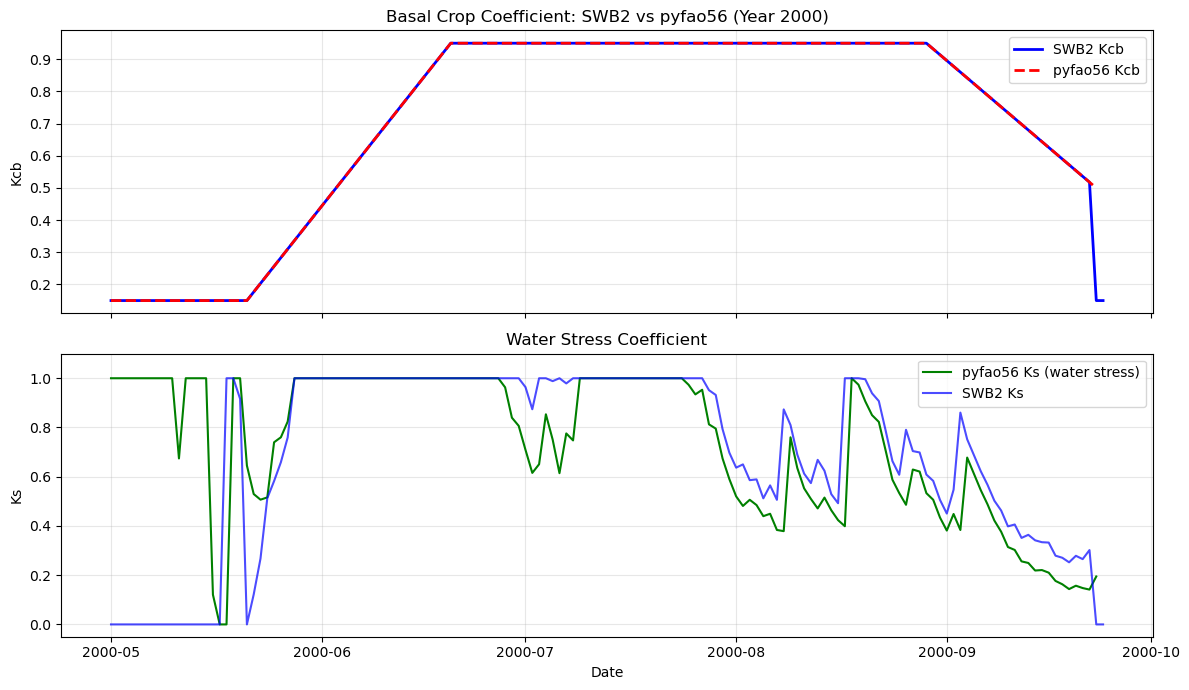

In [20]:
# Align SWB2 data to the pyfao56 date range
swb_gs = swb_df[(swb_df['date'] >= '2000-05-01') & (swb_df['date'] <= '2000-09-24')].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(swb_gs['date'], swb_gs['crop_coefficient_kcb'], 'b-', label='SWB2 Kcb', linewidth=2)
ax.plot(pyfao_df['date'], pyfao_df['Kcb'], 'r--', label='pyfao56 Kcb', linewidth=2)
ax.set_ylabel('Kcb')
ax.set_title('Basal Crop Coefficient: SWB2 vs pyfao56 (Year 2000)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(pyfao_df['date'], pyfao_df['Ks'], 'g-', label='pyfao56 Ks (water stress)')
# SWB2 also outputs Ks if available
if 'plant_stress_coef_ks' in swb_gs.columns:
    ax.plot(swb_gs['date'], swb_gs['plant_stress_coef_ks'], 'b-', label='SWB2 Ks', alpha=0.7)
ax.set_ylabel('Ks')
ax.set_xlabel('Date')
ax.set_title('Water Stress Coefficient')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

## Comparison: Actual ET

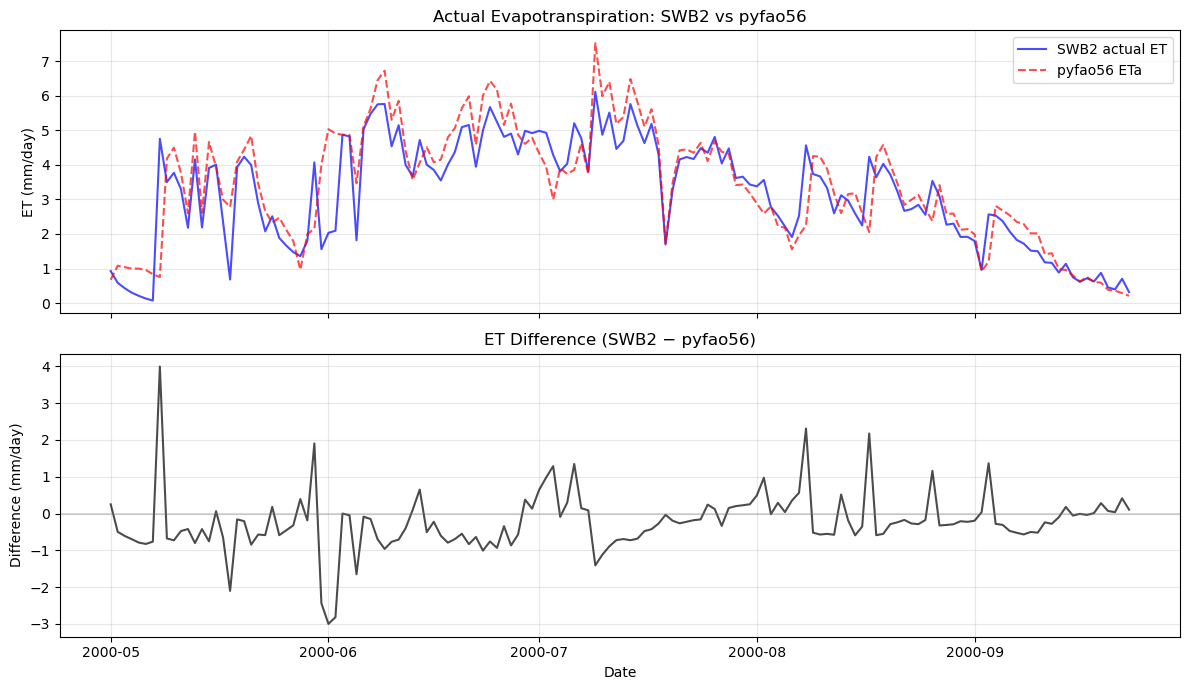

Mean SWB2 ETa: 3.17 mm/day
Mean pyfao56 ETa: 3.39 mm/day


In [21]:
# Merge on date for direct comparison
merged = swb_gs.merge(pyfao_df[['date', 'Kcb', 'Ks', 'ETa', 'Dr', 'TAW', 'Ke', 'Kr', 'E', 'T', 'Zr']],
                      on='date', how='inner')

# SWB2 actual_ET is in inches; convert to mm
merged['swb_ETa_mm'] = merged['actual_ET'] * 25.4

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(merged['date'], merged['swb_ETa_mm'], 'b-', label='SWB2 actual ET', alpha=0.7)
ax.plot(merged['date'], merged['ETa'], 'r--', label='pyfao56 ETa', alpha=0.7)
ax.set_ylabel('ET (mm/day)')
ax.set_title('Actual Evapotranspiration: SWB2 vs pyfao56')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(merged['date'], merged['swb_ETa_mm'] - merged['ETa'], 'k-', alpha=0.7)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_ylabel('Difference (mm/day)')
ax.set_xlabel('Date')
ax.set_title('ET Difference (SWB2 − pyfao56)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Mean SWB2 ETa: {merged["swb_ETa_mm"].mean():.2f} mm/day')
print(f'Mean pyfao56 ETa: {merged["ETa"].mean():.2f} mm/day')

## Comparison: Root Zone Depletion

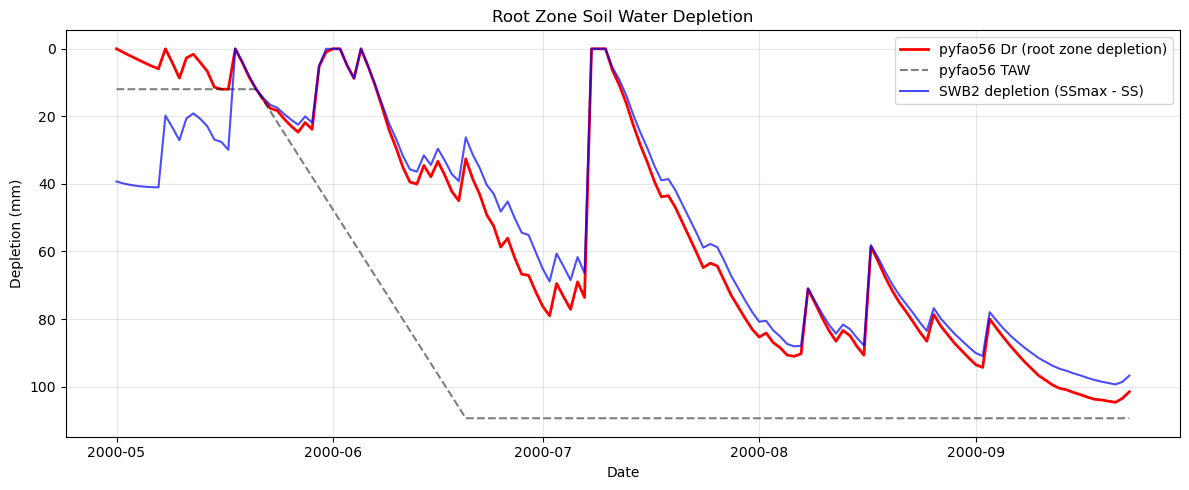

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(merged['date'], merged['Dr'], 'r-', label='pyfao56 Dr (root zone depletion)', linewidth=2)
ax.plot(merged['date'], merged['TAW'], 'k--', label='pyfao56 TAW', alpha=0.5)

# SWB2's soil moisture deficit (soil_storage_max - soil_storage) in mm
if 'soil_storage_max' in merged.columns and 'soil_storage' in merged.columns:
    swb_depletion = (merged['soil_storage_max'] - merged['soil_storage']) * 25.4
    ax.plot(merged['date'], swb_depletion, 'b-', label='SWB2 depletion (SSmax - SS)', alpha=0.7)

ax.set_ylabel('Depletion (mm)')
ax.set_xlabel('Date')
ax.set_title('Root Zone Soil Water Depletion')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Detailed FAO-56 component comparison

Compare the intermediate FAO-56 calculations between SWB2 and pyfao56:
- **Kr** — evaporation reduction coefficient
- **Ke** — surface evaporation coefficient
- **Zr** — rooting depth
- **ET partitioning** — bare soil evaporation vs transpiration

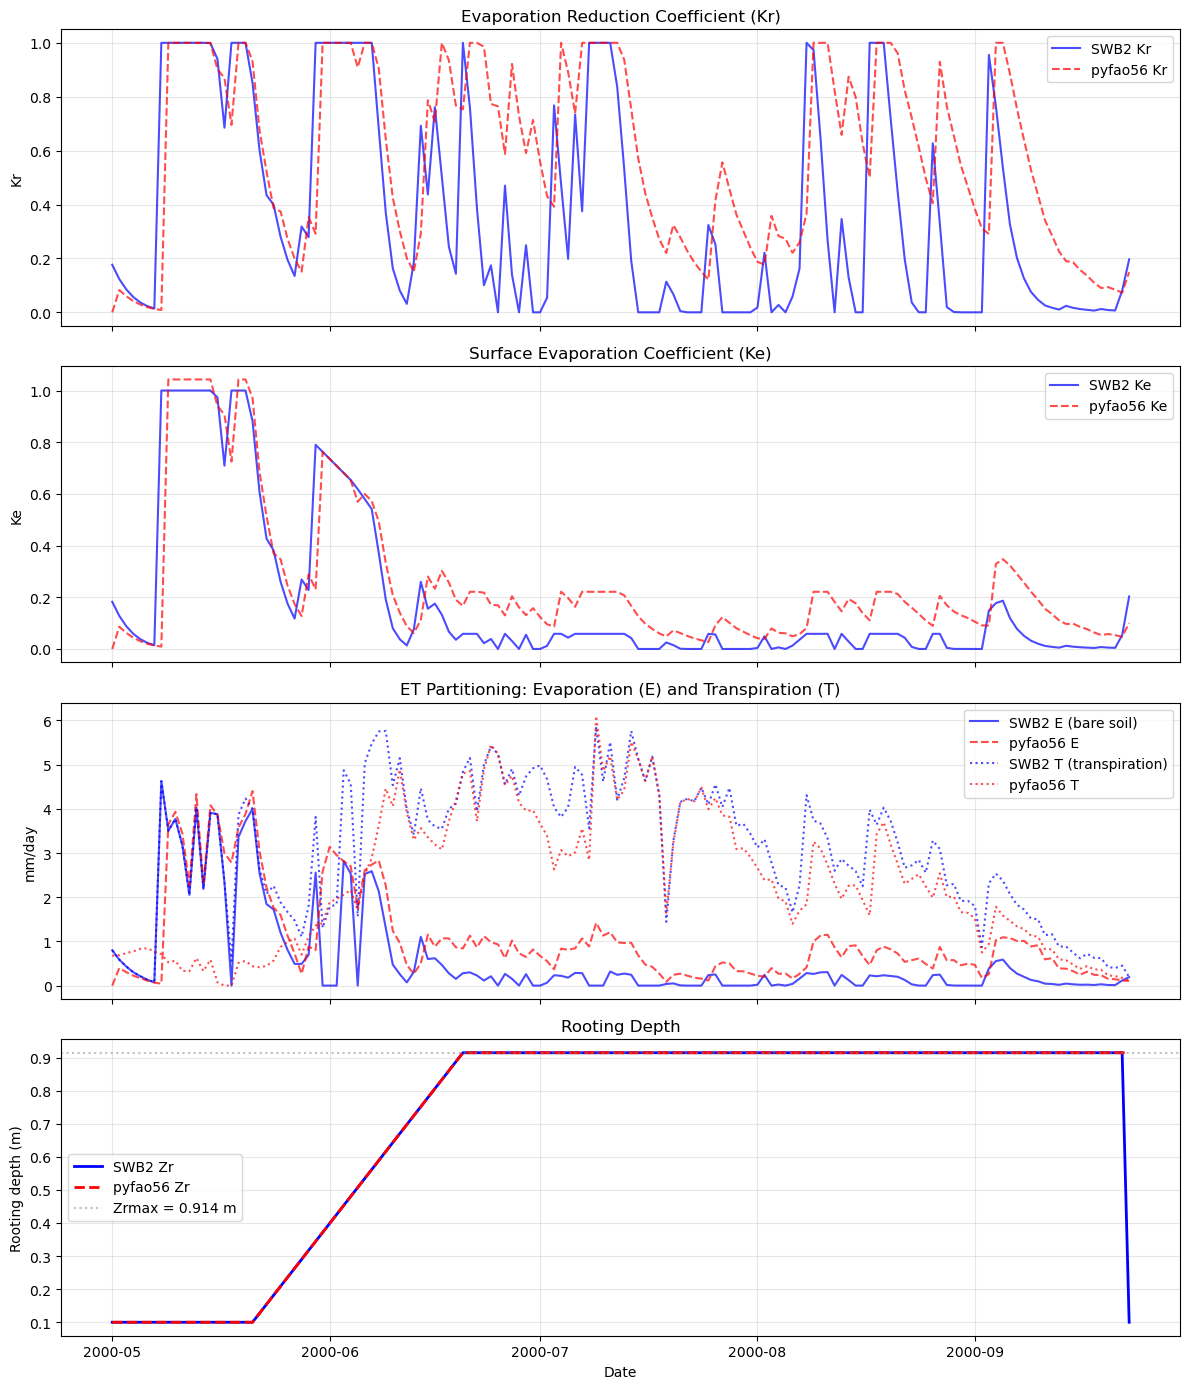

In [23]:
# Cross-walk between variable names:
# pyfao56         SWB2 (DUMP_VARIABLES)
# -------         ---------------------
# Kr              evap_reduction_coef_kr
# Ke              surf_evap_coef_ke
# E               bare_soil_evap (inches, need *25.4)
# T               actual_et_soil (inches, need *25.4)
# Zr              current_rooting_depth (feet, need *0.3048)
# Ks              plant_stress_coef_ks

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

# Kr comparison
ax = axes[0]
if 'evap_reduction_coef_kr' in merged.columns:
    ax.plot(merged['date'], merged['evap_reduction_coef_kr'], 'b-', label='SWB2 Kr', alpha=0.7)
ax.plot(merged['date'], merged['Kr'], 'r--', label='pyfao56 Kr', alpha=0.7)
ax.set_ylabel('Kr')
ax.set_title('Evaporation Reduction Coefficient (Kr)')
ax.legend()
ax.grid(True, alpha=0.3)

# Ke comparison
ax = axes[1]
if 'surf_evap_coef_ke' in merged.columns:
    ax.plot(merged['date'], merged['surf_evap_coef_ke'], 'b-', label='SWB2 Ke', alpha=0.7)
ax.plot(merged['date'], merged['Ke'], 'r--', label='pyfao56 Ke', alpha=0.7)
ax.set_ylabel('Ke')
ax.set_title('Surface Evaporation Coefficient (Ke)')
ax.legend()
ax.grid(True, alpha=0.3)

# ET partitioning: bare soil evaporation vs transpiration
ax = axes[2]
if 'bare_soil_evap' in merged.columns:
    ax.plot(merged['date'], merged['bare_soil_evap'] * 25.4, 'b-', label='SWB2 E (bare soil)', alpha=0.7)
ax.plot(merged['date'], merged['E'], 'r--', label='pyfao56 E', alpha=0.7)
if 'actual_et_soil' in merged.columns:
    ax.plot(merged['date'], merged['actual_et_soil'] * 25.4, 'b:', label='SWB2 T (transpiration)', alpha=0.7)
ax.plot(merged['date'], merged['T'], 'r:', label='pyfao56 T', alpha=0.7)
ax.set_ylabel('mm/day')
ax.set_title('ET Partitioning: Evaporation (E) and Transpiration (T)')
ax.legend()
ax.grid(True, alpha=0.3)

# Rooting depth
ax = axes[3]
if 'current_rooting_depth' in merged.columns:
    ax.plot(merged['date'], merged['current_rooting_depth'] * 0.3048, 'b-', label='SWB2 Zr', linewidth=2)
ax.plot(merged['date'], merged['Zr'], 'r--', label='pyfao56 Zr', linewidth=2)
ax.axhline(par.Zrmax, color='gray', linestyle=':', alpha=0.5, label=f'Zrmax = {par.Zrmax:.3f} m')
ax.set_ylabel('Rooting depth (m)')
ax.set_xlabel('Date')
ax.set_title('Rooting Depth')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Drought scenario: exercising the water stress pathway

The comparison above shows little water stress because Minnesota receives sufficient rainfall. To exercise the Ks pathway in both codes, we create a modified weather input with a 30-day drought imposed during July, then re-run both SWB2 and pyfao56.

In [24]:
import subprocess
import sys
sys.path.append(str(pl.Path.cwd().parent / 'python'))
import run_management as rm

# Create modified weather file: zero precipitation July 1-31, 2000
test_data_dir = pl.Path.cwd().parent / 'test_data'
wth_orig = pd.read_csv(test_data_dir / 'Minnesota_PRISM_daily_weather__US-Ro6__col_358__row_519__x_232693__y_2415326.tsv',
                        sep='\\t')
wth_orig['date_parsed'] = pd.to_datetime(wth_orig['date'])

# Zero out precip for July 2000
wth_drought = wth_orig.copy()
drought_mask = (wth_drought['date_parsed'] >= '2000-07-01') & (wth_drought['date_parsed'] <= '2000-07-31')
wth_drought.loc[drought_mask, 'prcp'] = 0.0

# Save modified weather file
drought_weather_file = test_data_dir / 'Minnesota_PRISM_daily_weather__drought_july2000.tsv'
wth_drought[['date', 'prcp', ' tmax', ' tmin']].to_csv(drought_weather_file, sep='\t', index=False)
print(f'Created drought weather file: {drought_weather_file.name}')
print(f'July 2000 precip sum: {wth_drought.loc[drought_mask, "prcp"].sum():.1f} (should be 0)')

Created drought weather file: Minnesota_PRISM_daily_weather__drought_july2000.tsv
July 2000 precip sum: 0.0 (should be 0)


C:\Users\smwesten\AppData\Local\Temp\1\ipykernel_31268\3417921840.py:8: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  wth_orig = pd.read_csv(test_data_dir / 'Minnesota_PRISM_daily_weather__US-Ro6__col_358__row_519__x_232693__y_2415326.tsv',


In [25]:
# Create a modified control file pointing to the drought weather
ctl_orig = (test_data_dir / 'swb_control_file_fao56_crop_coeff.ctl').read_text()
ctl_drought = ctl_orig.replace(
    'Minnesota_PRISM_daily_weather__US-Ro6__col_358__row_519__x_232693__y_2415326.tsv',
    'Minnesota_PRISM_daily_weather__drought_july2000.tsv')
drought_ctl = test_data_dir / 'swb_control_file_fao56_drought.ctl'
drought_ctl.write_text(ctl_drought)

# Run SWB2 with drought scenario
test_dir_drought = pl.Path.cwd().parent / 'test__fao56_drought'
logfile_dir_d = test_dir_drought / 'logfiles'
output_dir_d = test_dir_drought / 'output'
swb2_executable = str(pl.Path.cwd().parent / 'bin' / 'swb2.exe')

rm.destroy_model_work_output_and_logfile_dirs(base_dir=str(pl.Path.cwd().parent),
                                              test_dir=test_dir_drought,
                                              logfile_dir=logfile_dir_d,
                                              output_dir=output_dir_d)
rm.create_model_work_output_and_logfile_dirs(base_dir=str(pl.Path.cwd().parent),
                                             test_dir=test_dir_drought,
                                             logfile_dir=logfile_dir_d,
                                             output_dir=output_dir_d)

swb_args = [swb2_executable,
            f'--output_dir={output_dir_d}',
            f'--data_dir={test_data_dir}',
            f'--lookup_dir={test_data_dir}',
            f'--weather_data_dir={test_data_dir}',
            '--output_prefix=swb_drought_',
            f'--logfile_dir={logfile_dir_d}',
            str(drought_ctl)]

with rm.cd(test_dir_drought):
    p = subprocess.run(swb_args, capture_output=True, text=True, timeout=300)
print(f'SWB2 drought run return code: {p.returncode}')

SWB2 drought run return code: 0


In [26]:
# Load SWB2 drought results
drought_csv = list(output_dir_d.glob('SWB2_variable_values*.csv'))[0]
swb_drought = pd.read_csv(drought_csv)
swb_drought.columns = swb_drought.columns.str.strip()
swb_drought['date'] = pd.to_datetime(swb_drought['date'])

# Run pyfao56 with drought weather
wth_dry = fao.Weather()
wth_dry.wndht = 2.0
wdata_dry = wdata.copy()
# Zero rain for July 2000 (DOY 183-213)
july_idx = [i for i in wdata_dry.index if i.startswith('2000-') and 183 <= int(i.split('-')[1]) <= 213]
wdata_dry.loc[july_idx, 'Rain'] = 0.0
wth_dry.wdata = wdata_dry

mdl_dry = fao.Model('2000-122', '2000-267', par, wth_dry)
mdl_dry.run()
pyfao_dry = mdl_dry.odata.copy()
pyfao_dry = pyfao_dry.loc[:, ~pyfao_dry.columns.duplicated()]
pyfao_dry['date'] = pd.to_datetime(pyfao_dry['Date'])

print(f'pyfao56 drought: Ks min = {pyfao_dry["Ks"].min():.4f}')

pyfao56 drought: Ks min = 0.0000


C:\Users\smwesten\AppData\Local\Temp\1\ipykernel_31268\3814295501.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pyfao_dry['date'] = pd.to_datetime(pyfao_dry['Date'])


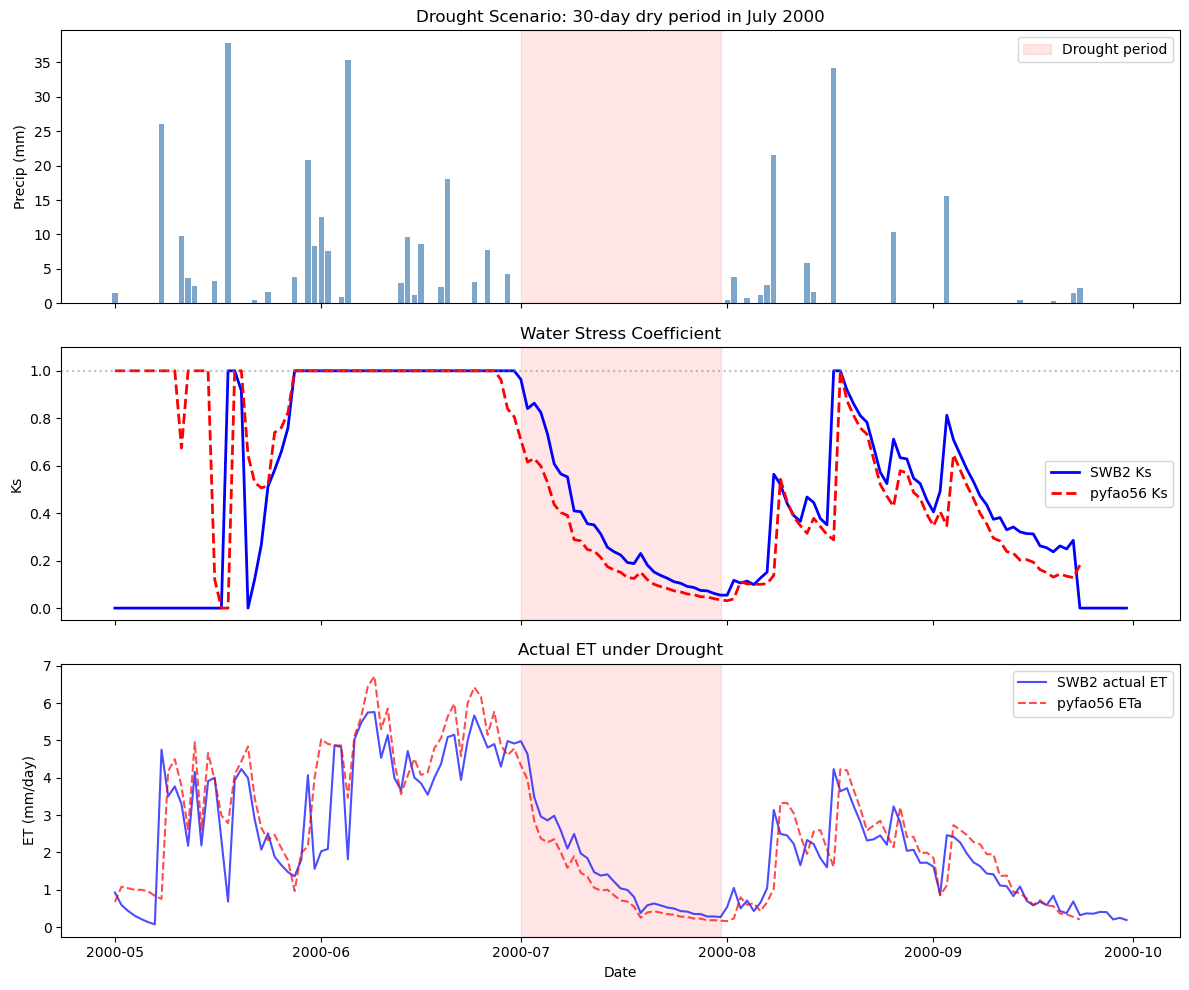

In [27]:
# Plot drought comparison
swb_dry_gs = swb_drought[(swb_drought['date'] >= '2000-05-01') & (swb_drought['date'] <= '2000-09-30')]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Precipitation
ax = axes[0]
ax.bar(swb_dry_gs['date'], swb_dry_gs['gross_precip'] * 25.4, color='steelblue', alpha=0.7)
ax.axvspan(pd.Timestamp('2000-07-01'), pd.Timestamp('2000-07-31'), alpha=0.1, color='red', label='Drought period')
ax.set_ylabel('Precip (mm)')
ax.set_title('Drought Scenario: 30-day dry period in July 2000')
ax.legend()

# Water stress coefficient
ax = axes[1]
if 'plant_stress_coef_ks' in swb_dry_gs.columns:
    ax.plot(swb_dry_gs['date'], swb_dry_gs['plant_stress_coef_ks'], 'b-', label='SWB2 Ks', linewidth=2)
ax.plot(pyfao_dry['date'], pyfao_dry['Ks'], 'r--', label='pyfao56 Ks', linewidth=2)
ax.axvspan(pd.Timestamp('2000-07-01'), pd.Timestamp('2000-07-31'), alpha=0.1, color='red')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax.set_ylabel('Ks')
ax.set_title('Water Stress Coefficient')
ax.set_ylim(-0.05, 1.1)
ax.legend()

# Actual ET
ax = axes[2]
ax.plot(swb_dry_gs['date'], swb_dry_gs['actual_ET'] * 25.4, 'b-', label='SWB2 actual ET', alpha=0.7)
merged_dry = swb_dry_gs.merge(pyfao_dry[['date', 'ETa']], on='date', how='inner')
ax.plot(merged_dry['date'], merged_dry['ETa'], 'r--', label='pyfao56 ETa', alpha=0.7)
ax.axvspan(pd.Timestamp('2000-07-01'), pd.Timestamp('2000-07-31'), alpha=0.1, color='red')
ax.set_ylabel('ET (mm/day)')
ax.set_xlabel('Date')
ax.set_title('Actual ET under Drought')
ax.legend()

plt.tight_layout()
plt.show()

## Summary

This comparison shows the SWB2 FAO-56 implementation alongside the independently-developed pyfao56 package. Key observations:

1. **Kcb curves** should be very similar since both implement the same trapezoidal FAO-56 interpolation.
2. **Actual ET differences** reflect implementation details: SWB2 uses a simplified Thornthwaite-Mather soil moisture accounting (or FAO-56 two-stage), while pyfao56 implements the full dual Kc approach with separate evaporation and transpiration components.
3. **Soil water depletion** patterns reflect differences in how each code handles deep percolation, runoff, and the soil water balance.
4. **Drought scenario** — Both codes show declining Ks during the imposed 30-day drought, confirming that the water stress pathway activates appropriately when depletion exceeds readily available water (RAW).

Agreement in the Kcb curve confirms the crop coefficient construction is correct. Differences in ET and depletion are expected and informative — they reflect design choices in SWB2's approach. These differences have been noted and a design document in the swb2 repo contains information on code changes to make the FAO56 implementation with respect to evaporation more consistent with the FAO56 documentation. 